# Power System Simulation
### From grid topology to practical grid decisions

This notebook shows the full workflow of our package. It is written as a demo, so every important result
is explained in text before the code cell that produces it.

The idea is simple:

1. First understand the grid topology.
2. Then calculate how the grid behaves over time.
3. Finally use both parts to study EV charging, transformer taps and line outages.

## How to read this notebook

The code cells are mainly here to prove that the package works. The explanations and figures are the
presentation part.

The long setup cells are not important to present. They only import libraries, define colors and create
a small demo grid for Assignment 3. The interesting parts are the figures and the short function calls.

In [1]:
import copy
from io import BytesIO
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from IPython.display import Image as NotebookImage, display
from PIL import Image
from power_grid_model import ComponentType, DatasetType, LoadGenType, WindingType, initialize_array

from power_system_simulation.ev_penetration import apply_ev_penetration
from power_system_simulation.graph_processing import GraphProcessor
from power_system_simulation.n_minus_one import calculate_n_minus_1
from power_system_simulation.pgm_processing import (
    aggregate_line_results,
    aggregate_node_voltage_results,
    create_load_batch_update,
    deserialize_pgm_json,
    read_json_file,
    read_load_profile,
    run_batch_power_flow,
)
from power_system_simulation.tap_optimization import optimize_tap_position
from power_system_simulation.time_series_analysis import run_time_series_power_flow

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent

NAVY = "#17324D"
BLUE = "#2A6FBB"
LIGHT_BLUE = "#B9DDF2"
ORANGE = "#F28E55"
GREEN = "#31A785"
GREY = "#AAB6C2"
RED = "#D95D67"
PAPER = "#F6F8FB"

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.figsize": (10, 4.8),
        "figure.facecolor": "white",
        "axes.facecolor": PAPER,
        "axes.edgecolor": "#D7DEE7",
        "axes.titleweight": "bold",
        "axes.titlesize": 13,
        "axes.labelcolor": NAVY,
        "text.color": NAVY,
        "font.size": 11,
        "grid.alpha": 0.30,
    }
)


def clean_axes(ax):
    ax.spines[["top", "right"]].set_visible(False)


print("Presentation setup ready")

Presentation setup ready


## Package workflow

The three assignments are connected. Assignment 1 gives the topology tools. Assignment 2 gives the
time-series power flow. Assignment 3 combines both to answer practical grid questions.

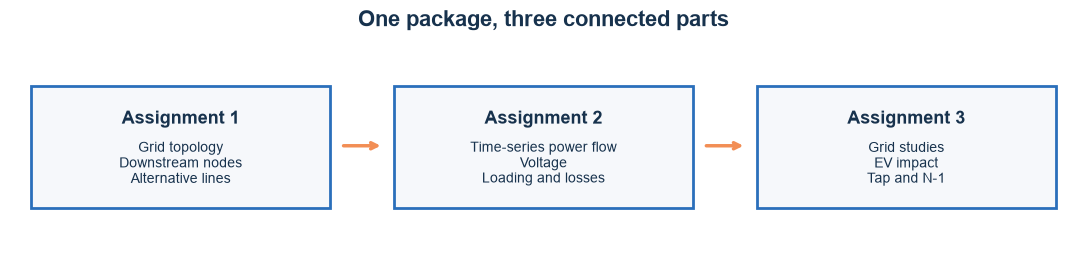

In [2]:
fig, ax = plt.subplots(figsize=(11, 2.8))
ax.axis("off")
steps = [
    ("Assignment 1", "Grid topology\nDownstream nodes\nAlternative lines"),
    ("Assignment 2", "Time-series power flow\nVoltage\nLoading and losses"),
    ("Assignment 3", "Grid studies\nEV impact\nTap and N-1"),
]
for i, (title, body) in enumerate(steps):
    x = i * 0.34 + 0.02
    box = plt.Rectangle((x, 0.22), 0.28, 0.55, facecolor=PAPER, edgecolor=BLUE, linewidth=2)
    ax.add_patch(box)
    ax.text(x + 0.14, 0.62, title, ha="center", va="center", fontsize=13, fontweight="bold")
    ax.text(x + 0.14, 0.42, body, ha="center", va="center", fontsize=10)
    if i < 2:
        ax.annotate(
            "",
            xy=(x + 0.33, 0.50),
            xytext=(x + 0.29, 0.50),
            arrowprops={"arrowstyle": "->", "lw": 2.5, "color": ORANGE},
        )
ax.set_title("One package, three connected parts", fontsize=16, fontweight="bold")
plt.tight_layout()

# 1. Understanding the grid topology

An LV grid is normally operated as a tree. This means there is one path from the transformer to every
house. Some lines can be present in the data but switched off. These are useful backup lines.

For this part we store the grid as one table with one row per line. This avoids the problem of keeping
separate lists of line IDs, endpoints and status values in sync.

In [3]:
edge_table = pd.DataFrame(
    {
        "edge_id": [4, 5, 8, 11, 24],
        "from_vertex": [3, 3, 6, 7, 9],
        "to_vertex": [6, 7, 9, 12, 12],
        "enabled": [True, True, True, True, False],
    }
)

graph = GraphProcessor(edge_table, source_vertex_id=3)
edge_table

,edge_id,from_vertex,to_vertex,enabled
0,4,3,6,True
1,5,3,7,True
2,8,6,9,True
3,11,7,12,True
4,24,9,12,False


## What happens when a line fails?

If line 8 fails, the graph is split into two parts. The package first finds the downstream nodes. Then it
checks the disabled lines and selects the ones that connect the two parts again.

For this small grid, node 9 is downstream of line 8 and line 24 can be used as backup.

In [4]:
outage_line = 8
downstream_nodes = graph.find_downstream_vertices(outage_line)
alternative_lines = graph.find_alternative_edges(outage_line)

pd.DataFrame(
    {
        "Question": ["Affected downstream nodes", "Possible backup lines"],
        "Result": [downstream_nodes, alternative_lines],
    }
)

,Question,Result
0,Affected downstream nodes,[9]
1,Possible backup lines,[24]


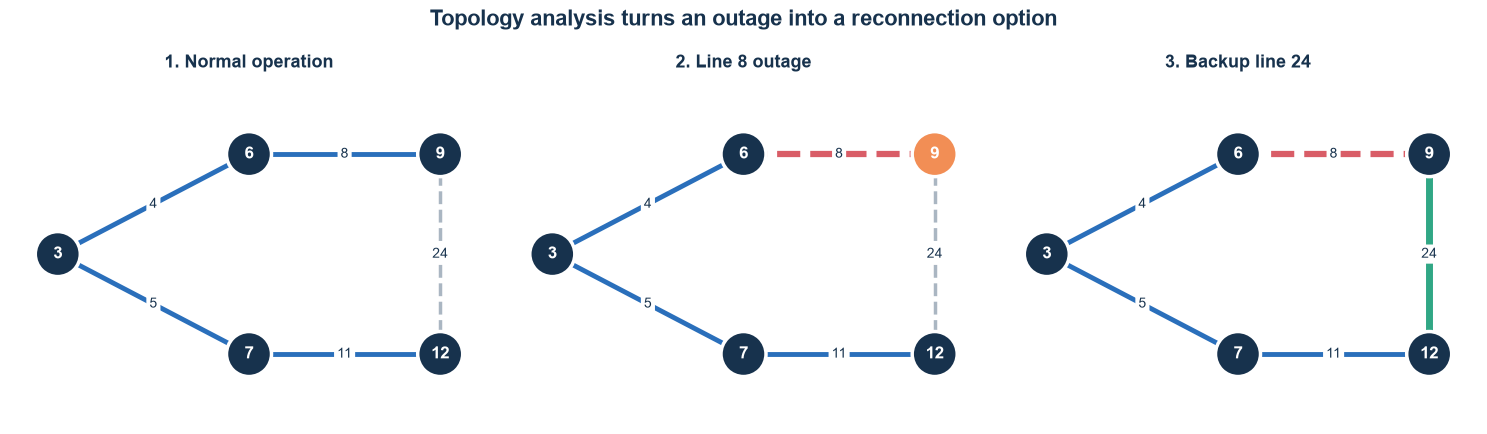

In [5]:
def draw_topology(ax, title, outage=None, connected_alternative=None, highlight_nodes=None):
    positions = {3: (0, 1), 6: (1, 1.5), 7: (1, 0.5), 9: (2, 1.5), 12: (2, 0.5)}
    grid_graph = nx.Graph()
    grid_graph.add_nodes_from(positions)
    for row in edge_table.itertuples():
        grid_graph.add_edge(row.from_vertex, row.to_vertex, edge_id=row.edge_id)

    ax.set_facecolor(PAPER)
    node_colors = [ORANGE if n in (highlight_nodes or []) else NAVY for n in grid_graph.nodes]
    nx.draw_networkx_nodes(
        grid_graph,
        positions,
        node_color=node_colors,
        edgecolors="white",
        linewidths=2.5,
        node_size=1050,
        ax=ax,
    )
    nx.draw_networkx_labels(grid_graph, positions, font_color="white", font_weight="bold", ax=ax)

    for row in edge_table.itertuples():
        color, style, width = BLUE, "solid", 3.5
        if not row.enabled:
            color, style, width = GREY, "dashed", 2.5
        if row.edge_id == outage:
            color, style, width = RED, "dashed", 4.5
        if row.edge_id == connected_alternative:
            color, style, width = GREEN, "solid", 5
        nx.draw_networkx_edges(
            grid_graph,
            positions,
            [(row.from_vertex, row.to_vertex)],
            edge_color=color,
            style=style,
            width=width,
            ax=ax,
        )
        midpoint = (
            (positions[row.from_vertex][0] + positions[row.to_vertex][0]) / 2,
            (positions[row.from_vertex][1] + positions[row.to_vertex][1]) / 2,
        )
        ax.text(
            *midpoint,
            str(row.edge_id),
            ha="center",
            va="center",
            fontsize=10,
            bbox={"boxstyle": "round,pad=0.22", "facecolor": "white", "edgecolor": "none"},
        )
    ax.set_title(title, pad=12)
    ax.set_xlim(-0.25, 2.25)
    ax.set_ylim(0.15, 1.85)
    ax.axis("off")


fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
draw_topology(axes[0], "1. Normal operation")
draw_topology(axes[1], "2. Line 8 outage", outage=8, highlight_nodes=downstream_nodes)
draw_topology(axes[2], "3. Backup line 24", outage=8, connected_alternative=24)
fig.suptitle("Topology analysis turns an outage into a reconnection option", fontsize=16, fontweight="bold")
plt.tight_layout()

# 2. Time-series power flow

A single power flow only gives one snapshot. In Assignment 2 we run the whole load profile in one batch.
This gives a result for every timestamp.

The output is summarized into two tables:

- one table for node voltages;
- one table for line loading and energy losses.

In [6]:
grid_data = deserialize_pgm_json(read_json_file(ROOT / "data" / "input_network_data.json"))
load_p = read_load_profile(ROOT / "data" / "active_power_profile.parquet")
load_q = read_load_profile(ROOT / "data" / "reactive_power_profile.parquet")

batch_update = create_load_batch_update(load_p, load_q)
results = run_batch_power_flow(grid_data, batch_update)
voltage_table = aggregate_node_voltage_results(results, load_p.index)
line_table = aggregate_line_results(results, load_p.index)

display(voltage_table.head(3).round(5))
display(line_table.round(4))

,max_u_pu,max_u_pu_node_id,min_u_pu,min_u_pu_node_id
timestamp,,,,
2024-01-01 00:00:00,1.00485,1,1.00345,3
2024-01-01 01:00:00,1.01205,3,1.00800,1
2024-01-01 02:00:00,0.99747,1,0.98437,4


C:\Users\20223081\AppData\Local\Temp\ipykernel_5020\3908661558.py:11: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(line_table.round(4))


,max_loading_pu,max_loading_timestamp,min_loading_pu,min_loading_timestamp,energy_loss_kwh
line_id,,,,,
5,0.1498,2024-01-01 06:00:00,0.0638,2024-01-01 03:00:00,63.2948
6,0.1110,2024-01-01 05:00:00,0.0372,2024-01-01 00:00:00,36.7751
7,0.0717,2024-01-01 02:00:00,0.0204,2024-01-01 01:00:00,14.8724


## Input profiles

The active load profile is the input to the calculation. The individual loads can move up and down, but
the total load is easier to read in a presentation.

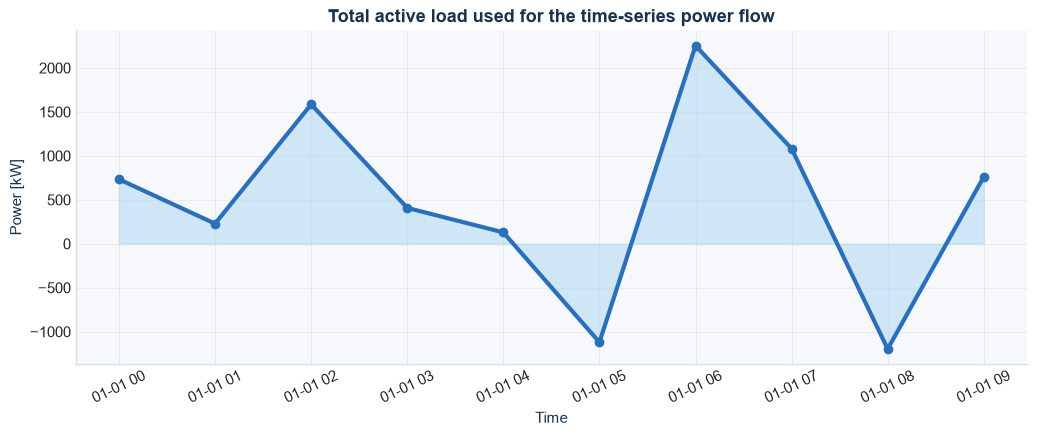

In [7]:
fig, ax = plt.subplots(figsize=(10.5, 4.5))
total_load_kw = load_p.sum(axis=1) / 1000
ax.plot(total_load_kw.index, total_load_kw, color=BLUE, linewidth=3, marker="o")
ax.fill_between(total_load_kw.index, total_load_kw, color=LIGHT_BLUE, alpha=0.65)
ax.set(title="Total active load used for the time-series power flow", ylabel="Power [kW]", xlabel="Time")
ax.tick_params(axis="x", rotation=25)
clean_axes(ax)
plt.tight_layout()

## Voltage result

The blue area shows the voltage range between the lowest and highest node voltage at each timestamp.
The dashed line is 1.0 p.u., which is the ideal reference voltage.

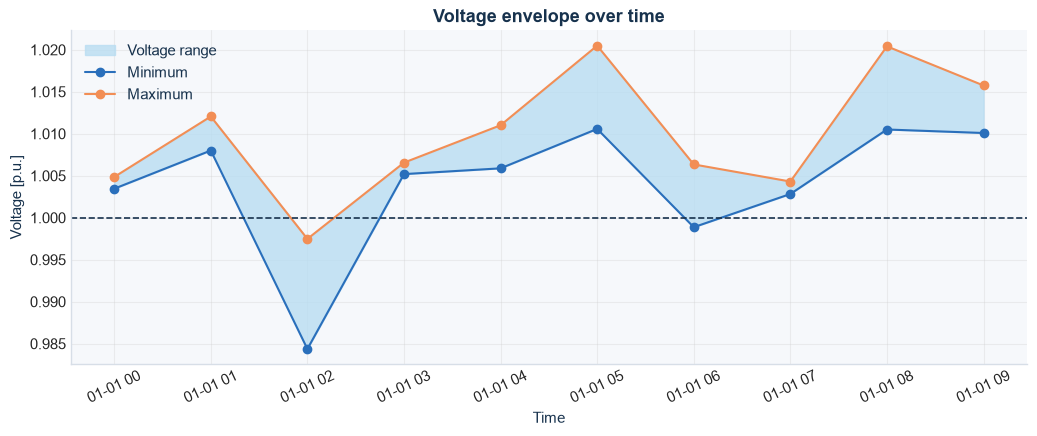

In [8]:
fig, ax = plt.subplots(figsize=(10.5, 4.5))
ax.fill_between(
    voltage_table.index,
    voltage_table["min_u_pu"],
    voltage_table["max_u_pu"],
    color=LIGHT_BLUE,
    alpha=0.8,
    label="Voltage range",
)
ax.plot(voltage_table.index, voltage_table["min_u_pu"], color=BLUE, marker="o", label="Minimum")
ax.plot(voltage_table.index, voltage_table["max_u_pu"], color=ORANGE, marker="o", label="Maximum")
ax.axhline(1.0, color=NAVY, linewidth=1.2, linestyle="--")
ax.set(title="Voltage envelope over time", ylabel="Voltage [p.u.]", xlabel="Time")
ax.tick_params(axis="x", rotation=25)
ax.legend(frameon=False)
clean_axes(ax)
plt.tight_layout()

## Line results

Line loading tells us how heavily each line is used. Energy loss tells us where power is lost as heat.
These are separated into two plots to keep the figures readable.

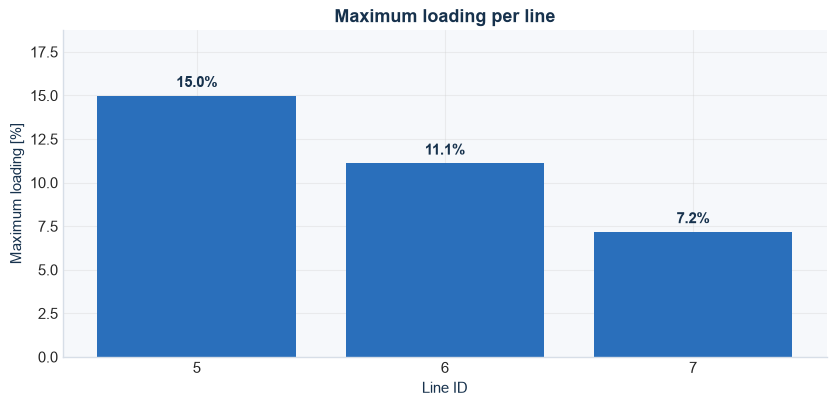

In [9]:
fig, ax = plt.subplots(figsize=(8.5, 4.2))
loading_percent = line_table["max_loading_pu"] * 100
bars = ax.bar(loading_percent.index.astype(str), loading_percent, color=BLUE)
ax.bar_label(bars, fmt="%.1f%%", padding=4, fontweight="bold")
ax.set(title="Maximum loading per line", ylabel="Maximum loading [%]", xlabel="Line ID")
ax.set_ylim(0, loading_percent.max() * 1.25)
clean_axes(ax)
plt.tight_layout()

Total energy loss: 114.9 kWh
Highest line loading: 0.150 p.u.


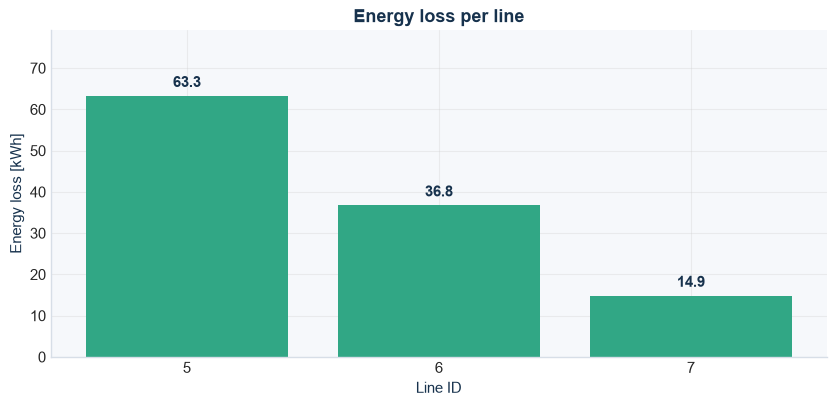

In [10]:
fig, ax = plt.subplots(figsize=(8.5, 4.2))
bars = ax.bar(line_table.index.astype(str), line_table["energy_loss_kwh"], color=GREEN)
ax.bar_label(bars, fmt="%.1f", padding=4, fontweight="bold")
ax.set(title="Energy loss per line", ylabel="Energy loss [kWh]", xlabel="Line ID")
ax.set_ylim(0, line_table["energy_loss_kwh"].max() * 1.25)
clean_axes(ax)
plt.tight_layout()

print(f"Total energy loss: {line_table['energy_loss_kwh'].sum():.1f} kWh")
print(f"Highest line loading: {line_table['max_loading_pu'].max():.3f} p.u.")

## Small but important detail

Energy loss is not just one value. We first get power loss at every timestamp and then integrate over
time. We used the trapezoidal rule:

```python
hours = (time_index - time_index[0]).total_seconds() / 3600
energy_loss_kwh = np.trapezoid(loss_w, hours) / 1000
```

This converts power loss in W into energy loss in kWh.

# 3. Practical grid studies

Assignment 3 combines the graph tools and the time-series power flow. The demo grid below is small so the
figures stay readable, but the same functions are written for a larger LV grid.

In [11]:
def create_demo_grid():
    nodes = initialize_array(DatasetType.input, ComponentType.node, 6)
    nodes["id"] = [1, 3, 6, 7, 9, 12]
    nodes["u_rated"] = [10500, 400, 400, 400, 400, 400]

    source = initialize_array(DatasetType.input, ComponentType.source, 1)
    source["id"], source["node"], source["status"] = 0, 1, 1
    source["u_ref"], source["sk"], source["rx_ratio"] = 1.0, 100e6, 0.1

    transformer = initialize_array(DatasetType.input, ComponentType.transformer, 1)
    transformer["id"], transformer["from_node"], transformer["to_node"] = 2, 1, 3
    transformer["from_status"], transformer["to_status"] = 1, 1
    transformer["u1"], transformer["u2"], transformer["sn"] = 10500, 400, 400e3
    transformer["uk"], transformer["pk"], transformer["i0"], transformer["p0"] = 0.04, 4000, 0, 0
    transformer["winding_from"], transformer["winding_to"], transformer["clock"] = (
        WindingType.delta,
        WindingType.wye_n,
        5,
    )
    transformer["tap_side"], transformer["tap_pos"], transformer["tap_min"] = 0, 0, -1
    transformer["tap_max"], transformer["tap_nom"], transformer["tap_size"] = 1, 0, 100

    lines = initialize_array(DatasetType.input, ComponentType.line, 5)
    lines["id"], lines["from_node"], lines["to_node"] = [4, 5, 8, 11, 24], [3, 3, 6, 7, 9], [6, 7, 9, 12, 12]
    lines["from_status"], lines["to_status"] = 1, [1, 1, 1, 1, 0]
    lines["r1"], lines["x1"], lines["c1"], lines["tan1"], lines["i_n"] = 0.05, 0.01, 0, 0, 200

    loads = initialize_array(DatasetType.input, ComponentType.sym_load, 2)
    loads["id"], loads["node"], loads["status"] = [10, 13], [9, 12], 1
    loads["type"], loads["p_specified"], loads["q_specified"] = LoadGenType.const_power, 0, 0
    return {
        ComponentType.node: nodes,
        ComponentType.source: source,
        ComponentType.transformer: transformer,
        ComponentType.line: lines,
        ComponentType.sym_load: loads,
    }


demo_grid = create_demo_grid()
demo_time = pd.date_range("2026-01-01", periods=3, freq="h")
demo_p = pd.DataFrame({10: [2000.0, 3000.0, 2500.0], 13: [2000.0, 2500.0, 3000.0]}, index=demo_time)
demo_q = pd.DataFrame({10: [500.0, 600.0, 550.0], 13: [500.0, 550.0, 600.0]}, index=demo_time)
ev_profiles = pd.DataFrame({"EV A": [0.0, 1000.0, 500.0], "EV B": [500.0, 0.0, 1000.0]}, index=demo_time)
print("Demo grid ready")

Demo grid ready


## 3A. EV penetration

EV charging is added to a selection of houses. The assignment also requires randomness, so we use a seed.
That means the random selection is repeatable and the result does not change between runs.

The function returns the same type of voltage and line tables as Assignment 2. That makes the base case
and EV case easy to compare.

In [12]:
base_voltage, base_lines = run_time_series_power_flow(demo_grid, demo_p, demo_q)
ev_voltage, ev_lines = apply_ev_penetration(
    demo_grid,
    feeder_ids=[4, 5],
    load_p=demo_p,
    load_q=demo_q,
    ev_profiles=ev_profiles,
    penetration=1.0,
    seed=4,
)

comparison = pd.DataFrame(
    {
        "Base case": [
            base_voltage["min_u_pu"].min(),
            base_lines["max_loading_pu"].max(),
            base_lines["energy_loss_kwh"].sum(),
        ],
        "100% EV": [
            ev_voltage["min_u_pu"].min(),
            ev_lines["max_loading_pu"].max(),
            ev_lines["energy_loss_kwh"].sum(),
        ],
    },
    index=["Minimum voltage [p.u.]", "Maximum loading [p.u.]", "Energy loss [kWh]"],
)
comparison.round(5)

,Base case,100% EV
Minimum voltage [p.u.],0.99778,0.99743
Maximum loading [p.u.],0.02213,0.02569
Energy loss [kWh],0.01764,0.02504


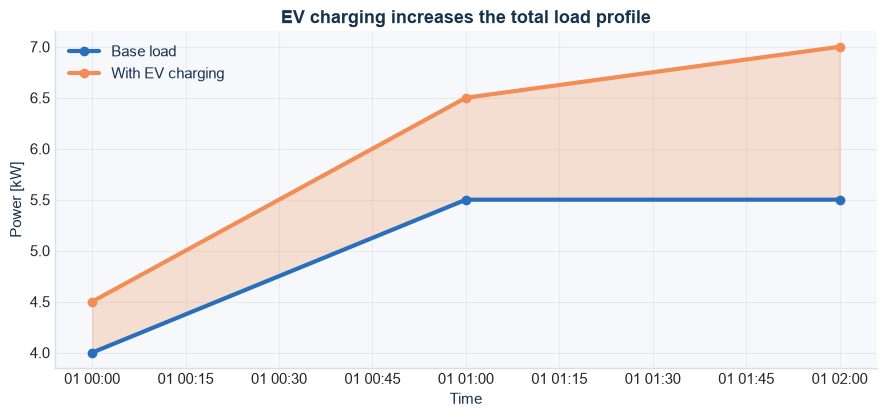

In [13]:
fig, ax = plt.subplots(figsize=(9, 4.3))
base_total_kw = demo_p.sum(axis=1) / 1000
ev_total_kw = (demo_p.sum(axis=1) + ev_profiles.sum(axis=1)) / 1000
ax.plot(base_total_kw.index, base_total_kw, color=BLUE, marker="o", linewidth=3, label="Base load")
ax.plot(ev_total_kw.index, ev_total_kw, color=ORANGE, marker="o", linewidth=3, label="With EV charging")
ax.fill_between(ev_total_kw.index, base_total_kw, ev_total_kw, color=ORANGE, alpha=0.25)
ax.set(title="EV charging increases the total load profile", ylabel="Power [kW]", xlabel="Time")
ax.legend(frameon=False)
clean_axes(ax)
plt.tight_layout()

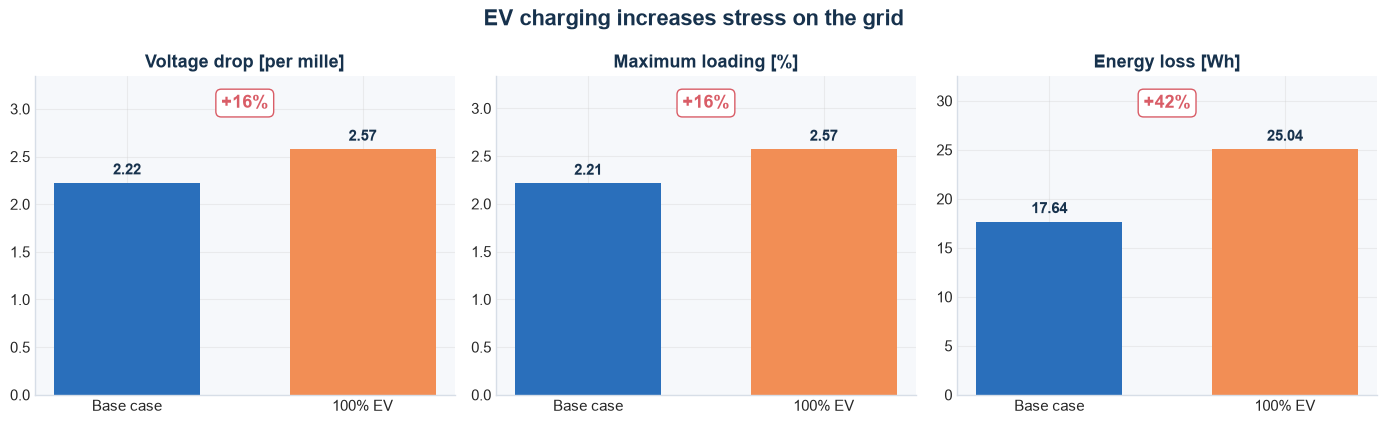

In [14]:
plot_comparison = pd.DataFrame(
    {
        "Base case": [
            (1 - comparison.loc["Minimum voltage [p.u.]", "Base case"]) * 1000,
            comparison.loc["Maximum loading [p.u.]", "Base case"] * 100,
            comparison.loc["Energy loss [kWh]", "Base case"] * 1000,
        ],
        "100% EV": [
            (1 - comparison.loc["Minimum voltage [p.u.]", "100% EV"]) * 1000,
            comparison.loc["Maximum loading [p.u.]", "100% EV"] * 100,
            comparison.loc["Energy loss [kWh]", "100% EV"] * 1000,
        ],
    },
    index=["Voltage drop [per mille]", "Maximum loading [%]", "Energy loss [Wh]"],
)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.3))
for ax, metric in zip(axes, plot_comparison.index, strict=True):
    values = plot_comparison.loc[metric]
    bars = ax.bar(values.index, values.values, color=[BLUE, ORANGE], width=0.62)
    ax.bar_label(bars, fmt="%.2f", padding=4, fontweight="bold")
    change = (values["100% EV"] / values["Base case"] - 1) * 100
    ax.text(
        0.5,
        0.90,
        f"+{change:.0f}%",
        transform=ax.transAxes,
        ha="center",
        color=RED,
        fontsize=13,
        fontweight="bold",
        bbox={"boxstyle": "round,pad=0.3", "facecolor": "white", "edgecolor": RED},
    )
    ax.set_title(metric)
    ax.set_ylim(bottom=0, top=values.max() * 1.30)
    clean_axes(ax)

fig.suptitle("EV charging increases stress on the grid", fontsize=16, fontweight="bold")
plt.tight_layout()

## 3B. Optimal transformer tap

A transformer tap changes the voltage level. We test every allowed tap position over the full time period.
There are two possible goals:

- reduce energy losses;
- keep voltages close to 1.0 p.u.

The important point is that these goals do not always select the same tap.

In [15]:
tap_rows = []
for tap in range(-1, 2):
    changed_grid = copy.deepcopy(demo_grid)
    changed_grid[ComponentType.transformer]["tap_pos"][0] = tap
    tap_results = run_batch_power_flow(changed_grid, create_load_batch_update(demo_p, demo_q))
    tap_lines = aggregate_line_results(tap_results, demo_p.index)
    node_voltages = tap_results[ComponentType.node]["u_pu"]
    tap_rows.append(
        {
            "tap": tap,
            "loss_kwh": tap_lines["energy_loss_kwh"].sum(),
            "voltage_criterion": np.mean(np.abs(node_voltages - 1)),
        }
    )

tap_sweep = pd.DataFrame(tap_rows).set_index("tap")
best_loss_tap = optimize_tap_position(demo_grid, demo_p, demo_q, criterion="loss")
best_voltage_tap = optimize_tap_position(demo_grid, demo_p, demo_q, criterion="voltage")
tap_sweep.round(6)

,loss_kwh,voltage_criterion
tap,,
-1,0.017309,0.007001
0,0.017645,0.001027
1,0.017984,0.008898


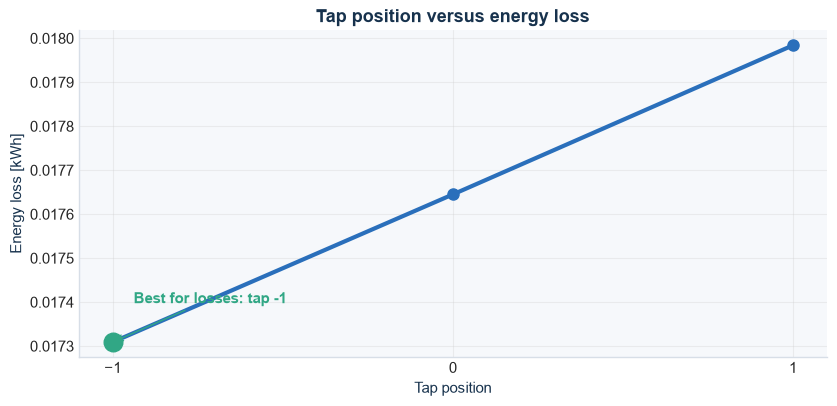

In [16]:
fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.plot(tap_sweep.index, tap_sweep["loss_kwh"], color=BLUE, marker="o", markersize=8, linewidth=3)
ax.scatter(best_loss_tap, tap_sweep.loc[best_loss_tap, "loss_kwh"], color=GREEN, s=180, zorder=5)
ax.annotate(
    f"Best for losses: tap {best_loss_tap}",
    (best_loss_tap, tap_sweep.loc[best_loss_tap, "loss_kwh"]),
    xytext=(15, 28),
    textcoords="offset points",
    color=GREEN,
    fontweight="bold",
    arrowprops={"arrowstyle": "->", "color": GREEN},
)
ax.set(title="Tap position versus energy loss", xlabel="Tap position", ylabel="Energy loss [kWh]")
ax.set_xticks(tap_sweep.index)
clean_axes(ax)
plt.tight_layout()

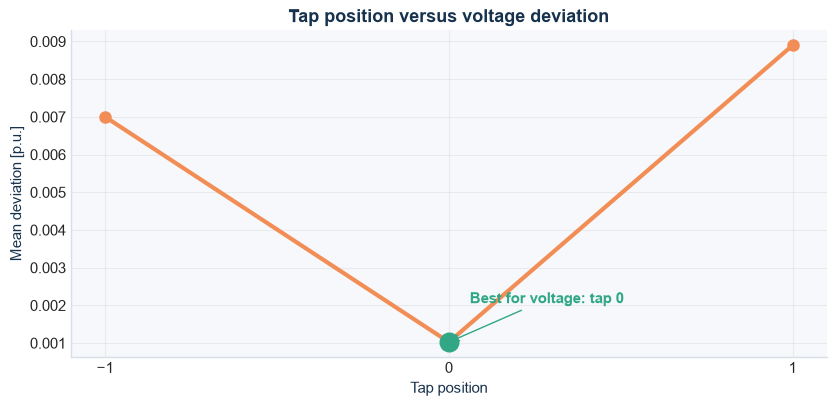

In [17]:
fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.plot(tap_sweep.index, tap_sweep["voltage_criterion"], color=ORANGE, marker="o", markersize=8, linewidth=3)
ax.scatter(best_voltage_tap, tap_sweep.loc[best_voltage_tap, "voltage_criterion"], color=GREEN, s=180, zorder=5)
ax.annotate(
    f"Best for voltage: tap {best_voltage_tap}",
    (best_voltage_tap, tap_sweep.loc[best_voltage_tap, "voltage_criterion"]),
    xytext=(15, 28),
    textcoords="offset points",
    color=GREEN,
    fontweight="bold",
    arrowprops={"arrowstyle": "->", "color": GREEN},
)
ax.set(title="Tap position versus voltage deviation", xlabel="Tap position", ylabel="Mean deviation [p.u.]")
ax.set_xticks(tap_sweep.index)
clean_axes(ax)
plt.tight_layout()

## 3C. N-1 analysis

N-1 means that the grid should still have a usable configuration when one line is out of service.

The function first uses the graph logic from Assignment 1 to find possible backup lines. Then it runs a
time-series power flow for every possible alternative and reports the worst loading.

In [18]:
n_minus_1_result = calculate_n_minus_1(demo_grid, demo_p, demo_q, outage_line_id=8)
n_minus_1_result.round(5)

C:\Users\20223081\AppData\Local\Temp\ipykernel_5020\347428980.py:2: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  n_minus_1_result.round(5)


,alternative_line_id,max_loading_pu,line_id,timestamp
0,24,0.04073,5,2026-01-01 01:00:00


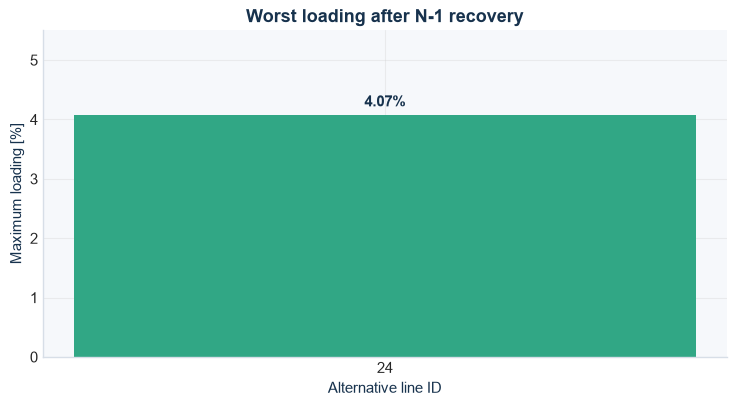

In [19]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
bars = ax.bar(
    n_minus_1_result["alternative_line_id"].astype(str),
    n_minus_1_result["max_loading_pu"] * 100,
    color=GREEN,
)
ax.bar_label(bars, fmt="%.2f%%", padding=4, fontweight="bold")
ax.set(title="Worst loading after N-1 recovery", xlabel="Alternative line ID", ylabel="Maximum loading [%]")
ax.set_ylim(0, (n_minus_1_result["max_loading_pu"] * 100).max() * 1.35)
clean_axes(ax)
plt.tight_layout()

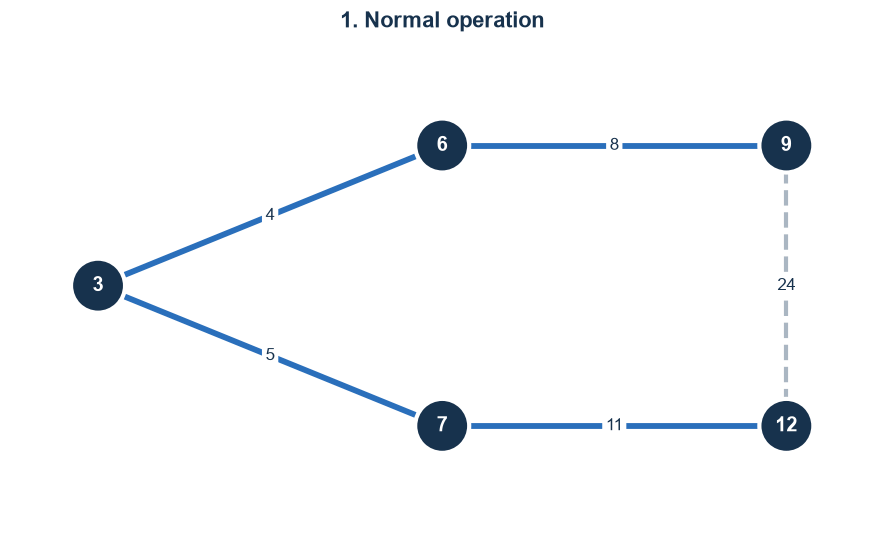

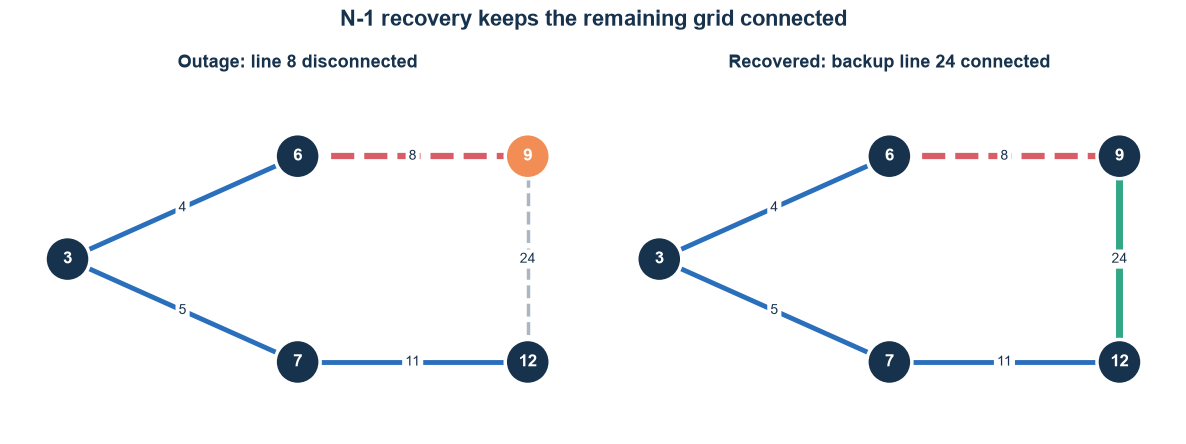

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
draw_topology(axes[0], "Outage: line 8 disconnected", outage=8, highlight_nodes=downstream_nodes)
draw_topology(axes[1], "Recovered: backup line 24 connected", outage=8, connected_alternative=24)
fig.suptitle("N-1 recovery keeps the remaining grid connected", fontsize=16, fontweight="bold")
plt.tight_layout()


def topology_frame(title, outage=None, alternative=None, highlighted=None):
    frame_figure, frame_axis = plt.subplots(figsize=(7.5, 4.6))
    draw_topology(
        frame_axis,
        title,
        outage=outage,
        connected_alternative=alternative,
        highlight_nodes=highlighted,
    )
    frame_figure.tight_layout()
    buffer = BytesIO()
    frame_figure.savefig(buffer, format="png", dpi=120, bbox_inches="tight")
    plt.close(frame_figure)
    buffer.seek(0)
    return Image.open(buffer).convert("RGB")


frames = [
    topology_frame("1. Normal operation"),
    topology_frame("2. Line 8 outage: node 9 disconnected", outage=8, highlighted=downstream_nodes),
    topology_frame("3. Backup line 24 restores supply", outage=8, alternative=24),
]
gif_path = ROOT / "example" / "n_minus_1_recovery.gif"
frames[0].save(gif_path, save_all=True, append_images=frames[1:], duration=[1100, 1400, 1800], loop=0)
display(NotebookImage(filename=str(gif_path)))

# Reliability

We also checked the boring but important parts:

- inputs are validated before calculations start;
- analysis functions use copies when they change grid settings;
- EV assignment is reproducible with a random seed;
- the full test suite passes with 100% code coverage.

This matters because the Assignment 3 functions combine several earlier parts. A small topology mistake
or a changed input grid would otherwise give wrong power-flow results later.

# Collaboration and lessons learned

We split Assignment 3 into separate files so different people could work on different parts:

- EV penetration;
- tap optimization;
- N-1 analysis;
- shared validation.

Pull requests were useful because several mistakes only became visible when the parts were combined.
The main lesson is that small shared interfaces are important. Assignment 3 became much easier once
Assignment 1 and 2 returned clear tables.

# Conclusion

The final package is useful because it connects topology and power-flow simulation.

It can:

1. find which part of the grid is affected by a line outage;
2. calculate voltages, loading and losses over time;
3. compare EV scenarios;
4. test transformer tap positions;
5. evaluate N-1 recovery options.

So the assignments are not three separate exercises anymore. Together they form one workflow for LV grid
analysis.